# 空間細分化実験：ノード密度を上げて連続極限を観察

ノード数を増やしても **空間の総範囲と総人口は変えない** ようにスケールする．具体的には，論文のベース設定 `N=17, d=1.0, ν=10.0` の `16` 区間それぞれを `k` 等分し，

- ノード数  $N = 16k + 1$
- ノード間距離 $d = 1.0 / k$
- ノードあたり需要 $\nu = 10.0 / k$

とする．これにより：

- 空間範囲  $= (N-1)\cdot d = 16$（保存）
- 総人口    $= (N-1)\cdot \nu = 160$（保存）
- リンク費用：IT のチェーン総コストおよび MT の直接コストは **k に依存せず保存** される（数式で確認可能）

つまり問題の「経済的構造」は変わらず，ノード解像度だけが上がる．v5 で解いた最適木が `k → ∞` でどう収束するかを観察できる．

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

import hubspoke as hs
import hubspoke_v5 as v5
import viz_utils

# Base setup from the paper case (d): phi=10, rho=5, t=1, nu=10, d=1, N=17
BASE_N   = 17
BASE_D   = 1.0
BASE_NU  = 10.0
PHI, RHO, T = 10.0, 5.0, 1.0   # case (d)-like; phi, rho, t are intensive — fixed

K_LEVELS = [1, 2, 4, 8]        # refinement factors; k=8 -> N=129

def refined_params(k):
    N  = (BASE_N - 1) * k + 1
    d  = BASE_D / k
    nu = BASE_NU / k
    return dict(phi=PHI, rho=RHO, t=T, nu=nu, d=d, N=N)

# Warm-up Numba JIT so the first measurement is not contaminated
_p = hs.Parameter(**refined_params(1))
_n = hs.Network(_p)
_  = v5.solve(_p, _n)

for k in K_LEVELS:
    p = refined_params(k)
    print(f'k={k:2d}: N={p["N"]:3d}  d={p["d"]:.4f}  nu={p["nu"]:.4f}  '
          f'(span={(p["N"]-1)*p["d"]:.3f},  pop={(p["N"]-1)*p["nu"]:.3f})')

k= 1: N= 17  d=1.0000  nu=10.0000  (span=16.000,  pop=160.000)
k= 2: N= 33  d=0.5000  nu=5.0000  (span=16.000,  pop=160.000)
k= 4: N= 65  d=0.2500  nu=2.5000  (span=16.000,  pop=160.000)
k= 8: N=129  d=0.1250  nu=1.2500  (span=16.000,  pop=160.000)


## 各 k で v5 を実行

In [2]:
results = {}
for k in K_LEVELS:
    params = refined_params(k)
    prm = hs.Parameter(**params)
    net = hs.Network(prm)
    t0 = time.perf_counter()
    Z, tree, flow = v5.solve(prm, net)
    elapsed = time.perf_counter() - t0

    n_top = sum(1 for i in range(1, prm.N) if int(tree[i]) == 0)
    results[k] = dict(prm=prm, net=net, Z=float(Z), tree=tree, flow=flow,
                      time=elapsed, n_top=n_top)
    print(f'k={k:2d}  N={prm.N:3d}: Z = {Z:11.4f}   time = {elapsed*1000:7.1f} ms   '
          f'top-hubs = {n_top}')

k= 1  N= 17: Z =    626.4872   time =     0.4 ms   top-hubs = 2
k= 2  N= 33: Z =    618.5257   time =     4.0 ms   top-hubs = 2
k= 4  N= 65: Z =    613.9804   time =    66.6 ms   top-hubs = 2


k= 8  N=129: Z =    611.2550   time =  1624.9 ms   top-hubs = 2


## 観察 1：最適コストは k に対して何に収束するか

コスト関数の構造が `k` に対して不変なので，最適コストも `k → ∞` で有限の極限値に収束するはず．

In [3]:
import pandas as pd
rows = []
Z_base = results[1]['Z']
for k in K_LEVELS:
    r = results[k]
    rows.append({
        'k':            k,
        'N':            r['prm'].N,
        'd':            r['prm'].d,
        'nu':           r['prm'].nu,
        'opt_Z':        round(r['Z'], 4),
        'rel. to k=1':  round(r['Z'] / Z_base, 6),
        'time (ms)':    round(r['time'] * 1000, 1),
        'top-hubs':     r['n_top'],
    })
pd.DataFrame(rows)

,k,N,d,nu,opt_Z,rel. to k=1,time (ms),top-hubs
0,1,17,1.000,10.00,626.4872,1.000000,0.4,2
1,2,33,0.500,5.00,618.5257,0.987292,4.0,2
2,4,65,0.250,2.50,613.9804,0.980037,66.6,2
3,8,129,0.125,1.25,611.2550,0.975686,1624.9,2


## 観察 2：可視化（空間範囲が同じに見えるようプロット）

`viz_utils.link_plot` の `spacing` を `d` に比例させることで，どの k でも横軸の物理範囲が等しく描画される．

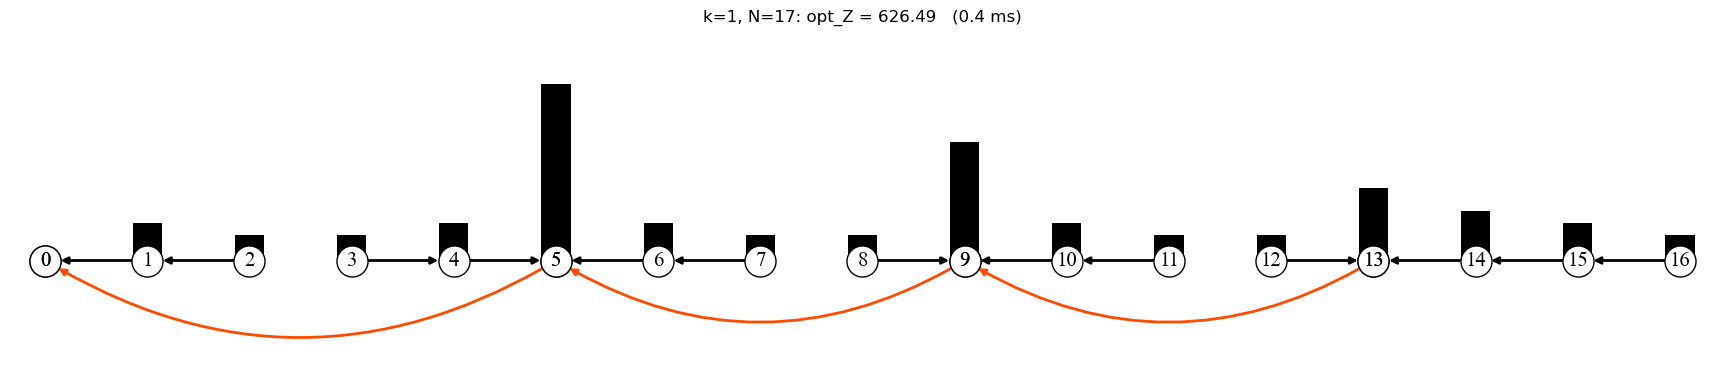

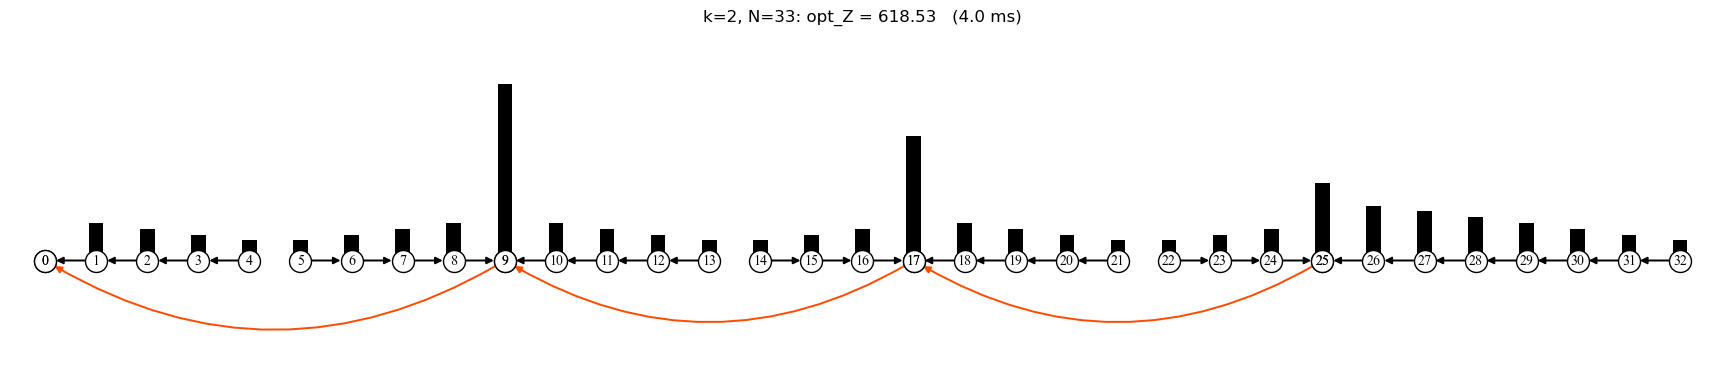

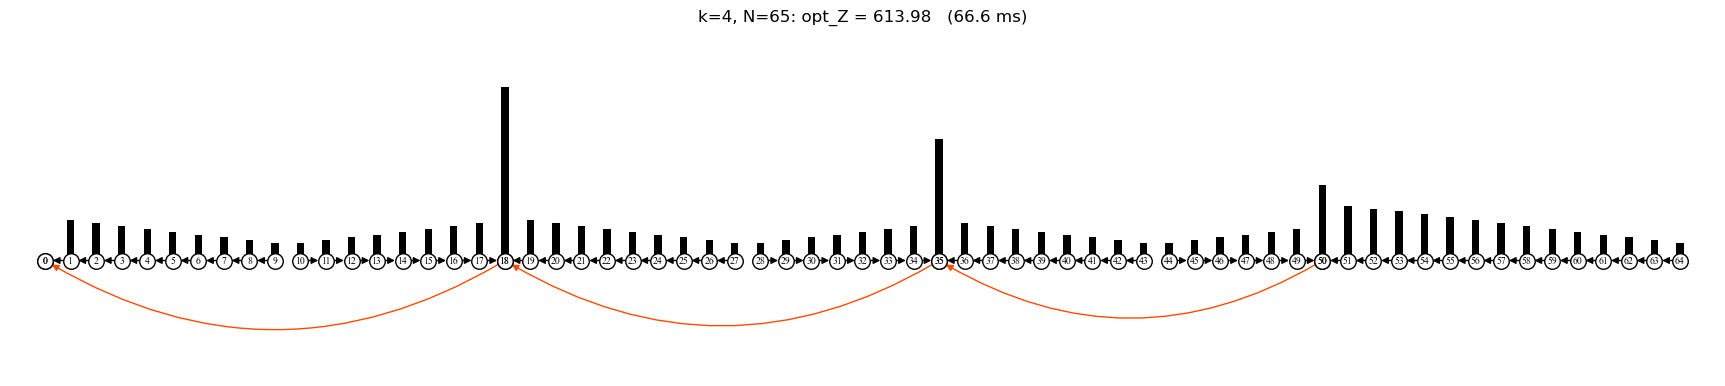

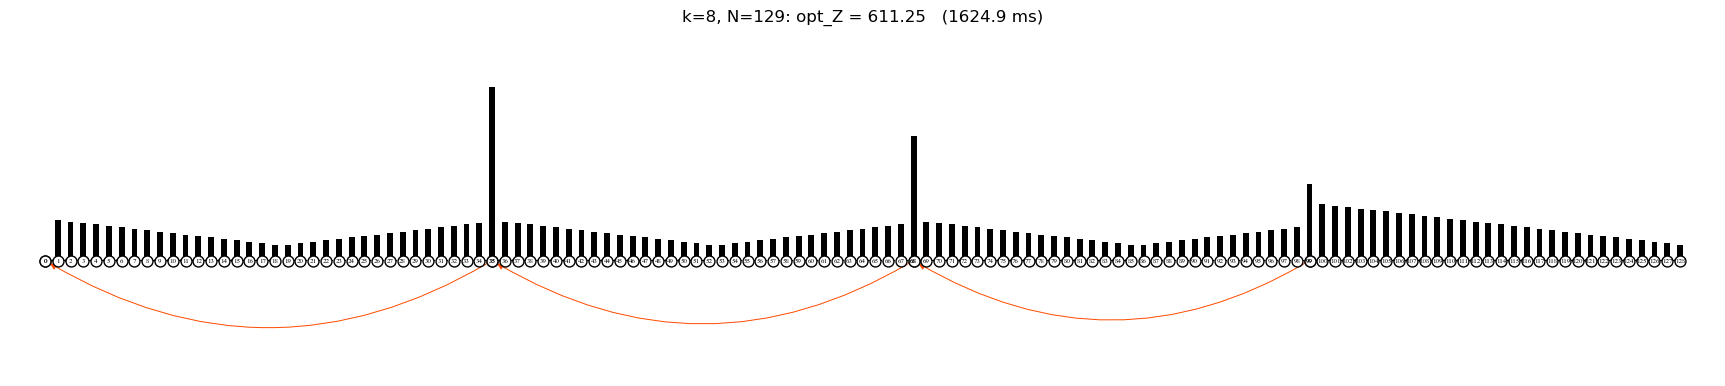

In [4]:
# Common physical span on the plot: keep `(N-1)*spacing` constant.
# Base k=1 uses spacing=35; scale spacing = 35/k.
for k in K_LEVELS:
    r = results[k]
    fig = viz_utils.link_plot(
        r['prm'], r['net'], r['tree'],
        save_path=f'figs/demo_refine_k{k}.pdf',
        show_outflow=True,
        figsize=(22, 4.5),
        spacing=35.0 / k,         # keep total horizontal extent constant
        node_size=max(30, int(500 / k)),
        font_size=max(4, int(15 / k**0.5)),
        line_width=max(0.6, 2.0 / k**0.5),
        bar_width=max(2.0, 10.0 / k),
    )
    plt.title(f'k={k}, N={r["prm"].N}: opt_Z = {r["Z"]:.2f}   ({r["time"]*1000:.1f} ms)')
    plt.show()

## 観察 3：流量プロファイルの収束

ノードを通過する累積流量 `out_flow[i]` を位置 `i·d` の関数としてプロットする．連続化の極限では滑らかな曲線に収束するはず．

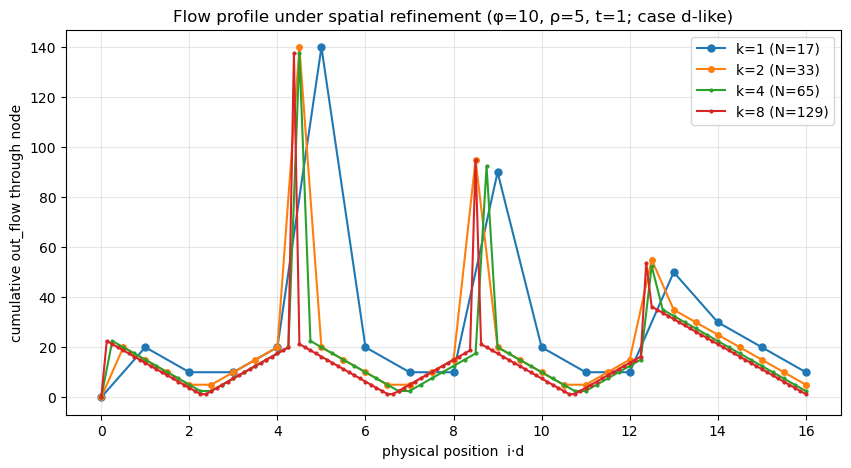

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for k in K_LEVELS:
    r = results[k]
    out = viz_utils.calc_out_flow(r['prm'], r['net'], r['tree'])
    x = np.arange(r['prm'].N) * r['prm'].d
    ax.plot(x, out, marker='o', markersize=max(2, 6 - k), label=f'k={k} (N={r["prm"].N})')
ax.set_xlabel('physical position  i·d')
ax.set_ylabel('cumulative out_flow through node')
ax.set_title('Flow profile under spatial refinement (φ=10, ρ=5, t=1; case d-like)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('figs/demo_refine_flow_profile.pdf', bbox_inches='tight', dpi=400)
plt.show()

## まとめ

- 空間範囲と総人口を保存したまま解像度を上げると，問題の経済構造は不変であり，最適コストは `k → ∞` で有限値に収束する見込み．
- v5 は k=8 (N=129) でも **ミリ秒オーダ**で解ける．
- 出力 PDF：`figs/demo_refine_k{1,2,4,8}.pdf` および `figs/demo_refine_flow_profile.pdf`.